# The Annotated DiffusionGemma

by Timothy Gao

For a high-level overview of diffusion LLMs and DiffusionGemma, refer to Google's official resources [Introducing DiffusionGemma](https://blog.google/innovation-and-ai/technology/developers-tools/diffusion-gemma-faster-text-generation/) and [DiffusionGemma Docs](https://ai.google.dev/gemma/docs/diffusiongemma/explained).

This notebook attempts to fill in the low-level details that were left out or only briefly covered in Google’s official documentation (e.g., the actual model architecture, partial RoPE, logit softcapping, Google's scalar-weight QK norm) and how exactly they are implemented (e.g., sampling, self-conditioning). We also discuss some implementation and inference tricks for DiffusionGemma: skipping computation on encode, lazy sampling, and RMSNorm fusion.

A working knowledge of vanilla autoregressive LLM implementations (Llama 3.1, MOE) is assumed.

![DiffusionGemma](model_arch.png)

# Setup + Load Model

In [30]:
!pip install -q -U huggingface_hub

In [31]:
!hf download google/diffusiongemma-26B-A4B-it --local-dir /content/diffusiongemma

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 22 files: 100% 22/22 [00:00<00:00, 956.59it/s]
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B                         ✓ Downloaded
  path: /content/diffusiongemma
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            


In [32]:
import glob, json, os # TODO: clean up imports
import torch
import torch.nn.functional as F
from einops import rearrange, einsum
from safetensors.torch import load_file
from tokenizers import Tokenizer
from tqdm import trange
from torch.distributions import Categorical

torch.set_default_dtype(torch.bfloat16)
# torch.set_default_device("cuda") # uncomment me to run on GPU (1 of 2)

In [33]:
max_tot_tokens = 2048
checkpoint = "diffusiongemma"
canvas_len = 256

In [34]:
model_config = json.load(open(f"{checkpoint}/config.json"))['text_config']
gen_config = json.load(open(f"{checkpoint}/generation_config.json"))
V = model_config['vocab_size']

model_config # describes details of the model

{'attention_bias': False,
 'attention_dropout': 0.0,
 'bos_token_id': 2,
 'dtype': 'bfloat16',
 'eos_token_id': 1,
 'final_logit_softcapping': 30.0,
 'global_head_dim': 512,
 'head_dim': 256,
 'hidden_activation': 'gelu_pytorch_tanh',
 'hidden_size': 2816,
 'initializer_range': 0.02,
 'intermediate_size': 2112,
 'layer_types': ['sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'full_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'full_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'full_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'full_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'sliding_attention',
  'full_attention

In [35]:
gen_config # describes how to sample from the model

{'confidence_threshold': 0.005,
 'eos_token_id': [1, 106, 50],
 'max_denoising_steps': 48,
 'max_new_tokens': 256,
 'pad_token_id': 0,
 'sampler_config': {'_cls_name': 'EntropyBoundSamplerConfig',
  'entropy_bound': 0.1},
 'stability_threshold': 1,
 't_max': 0.8,
 't_min': 0.4,
 'transformers_version': '5.8.0.dev0'}

In `model_config.json`, `eos_token_id` is `[1, 106]`.

In `generation_config.json`, it is `[1, 106, 50]`.

Token `50` is `<|tool_response>`, while tokens `1` and `106` are `<eos>` and `<turn|>`, respectively.

Llama 3 Instruct adds `<|eot_id|>` to only its generation configuration in the same way.

In [36]:
sd = {}
for safetensor_path in glob.glob(f"{checkpoint}/model-*.safetensors"):
    sd |= {k: v for k, v in load_file(safetensor_path).items() if "vision" not in k} # DiffusionGemma can also tokenize images
    # sd |= {k: v for k, v in load_file(safetensor_path, device="cuda").items() if "vision" not in k} # uncomment me to run on GPU (2 of 2), comment out previous line

In [37]:
sorted(list(sorted(sd.keys())))[:30]

['model.decoder.embed_tokens.weight',
 'model.decoder.layers.0.experts.down_proj',
 'model.decoder.layers.0.experts.gate_up_proj',
 'model.decoder.layers.0.input_layernorm.weight',
 'model.decoder.layers.0.layer_scalar',
 'model.decoder.layers.0.mlp.down_proj.weight',
 'model.decoder.layers.0.mlp.gate_proj.weight',
 'model.decoder.layers.0.mlp.up_proj.weight',
 'model.decoder.layers.0.post_attention_layernorm.weight',
 'model.decoder.layers.0.post_feedforward_layernorm.weight',
 'model.decoder.layers.0.post_feedforward_layernorm_1.weight',
 'model.decoder.layers.0.post_feedforward_layernorm_2.weight',
 'model.decoder.layers.0.pre_feedforward_layernorm.weight',
 'model.decoder.layers.0.pre_feedforward_layernorm_2.weight',
 'model.decoder.layers.0.router.per_expert_scale',
 'model.decoder.layers.0.router.proj.weight',
 'model.decoder.layers.0.router.scale',
 'model.decoder.layers.0.self_attn.k_norm.weight',
 'model.decoder.layers.0.self_attn.k_proj.weight',
 'model.decoder.layers.0.self_

In [38]:
W_vocab = sd['model.decoder.embed_tokens.weight']
print(W_vocab.shape, model_config['hidden_size'])
print(W_vocab.dtype)

# sd # uncomment me

torch.Size([262144, 2816]) 2816
torch.bfloat16


## Google's Scalar QK Normalization

Interestingly, all entries within each learned QK-normalization weight vector have the same value. For example:

```python
'model.decoder.layers.17.self_attn.q_norm.weight': tensor(
    [0.9883, 0.9883, 0.9883, 0.9883, 0.9883, 0.9883, 0.9883, 0.9883,
     0.9883, 0.9883, 0.9883, 0.9883, 0.9883, 0.9883, 0.9883, ...]
)
```

My interpretation:

 The QK-norm weight vectors have the form

$$
w_q = \gamma_q \mathbf{1},
\qquad
w_k = \gamma_k \mathbf{1},
$$

where $\gamma_q$ and $\gamma_k$ are the learned scalars.

$$
\begin{aligned}
\left\lVert \operatorname{RMSNorm}_{\gamma}(x) \right\rVert_2
&=
|\gamma|
\frac{\lVert x \rVert_2}
{\lVert x \rVert_2 / \sqrt{d_h}} \\
&=
|\gamma|\sqrt{d_h}.
\end{aligned}
$$

RoPE preserves Euclidean norm, so the same result holds after applying rotate:

$$
\lVert q \rVert_2
=
|\gamma_q|\sqrt{d_h},
\qquad
\lVert k \rVert_2
=
|\gamma_k|\sqrt{d_h}.
$$

For a query $q$ and key $k_i$ separated by an angle $\theta_i$,

$$
\langle q, k_i \rangle
=
d_h \gamma_q\gamma_k\cos\theta_i.
$$

Thus, the attention score for $k_i$ is

$$
\begin{aligned}
\operatorname{score}_q(k_i)
&\propto
\exp\!\left(\langle q, k_i \rangle\right) \\
&=
\exp\!\left(d_h\gamma_q\gamma_k\cos\theta_i\right) \\
&=
\exp\!\left(\frac{\cos\theta_i}{T}\right),
\end{aligned}
$$

where

$$
T
=
\frac{1}{d_h\gamma_q\gamma_k}
$$

is a fixed, learned effective attention temperature per layer.

In regular QK norm or non-QK norm models, magnitude of q and k can vary. This 1) produces a per-query-dependent effective temperature and 2) allows key magnitude to encode a form of query-independent importance in addition to angular alignment:

$$
\begin{aligned}
score_q(k_i)
&\propto
\exp\!\left(
\frac{\lVert k_i \rVert_2 \cos\theta_i}{T_q}
\right),
\end{aligned}
$$

where

$$
T_q
=
\frac{1}{\lVert q \rVert_2}
$$

This may be undesirable in long-context settings, where a high-magnitude early key could remain disproportionately influential even after its relevance has faded.

In [39]:
for layer_id in range(model_config["num_hidden_layers"]):
    for kind in ("q", "k"):
        w = sd[f"model.decoder.layers.{layer_id}.self_attn.{kind}_norm.weight"]
        assert (w == w[0]).all(), "QK Norm entries are not all equal"

We do RMSNorm in fp32 because precision errors are accumulated through the reduction, potentially amplified through the division, and propagated to every element.

$$
\operatorname{RMSNorm}_w(x)
=
\sqrt{d}\left(
w \odot
\frac{x}{\|x\|_2 + \epsilon}
\right)
$$

In [40]:
def rms(x, w = 1):
    return (w * x * (x.shape[-1] ** 0.5) / (torch.norm(x, dim=-1, keepdim=True, dtype=torch.float32) + model_config['rms_norm_eps'])).to(x.dtype)

## Rotary position embeddings

DiffusionGemma uses two RoPE configurations:

| Layer type | Head width | RoPE base $\theta$ | Rotated fraction |
|---|---:|---:|---:|
| Sliding attention | 256 | 10,000 | 100% |
| Full attention | 512 | 1,000,000 | 25% |

For a head of width $d$, standard RoPE defines one inverse frequency for each of the $d/2$ two-dimensional rotation planes:

$$
\omega_j = \theta^{-2j/d},
\qquad j=0,\ldots,d/2-1.
$$

The sliding-attention layers rotate every pair (standard RoPe). The full-attention layers use **partial RoPE**: the code first constructs the ordinary 512-dimensional frequency vector, then sets all but the first 25% of its pair frequencies to zero, thus those dimensions are unchanged after rotate. Notably, we are doing truncating the full frequency spectrum rather than rescaling it to a smaller rotary dimension.

Partial RoPE lets a head carry both explicitly position-sensitive features and features whose representation is not rotated as position changes.

In [41]:
print(model_config['head_dim'])
print(model_config['global_head_dim'])

256
512


The rows of $W_k$ and $W_q$ are stored arranged so that the projected vectors use split-half rotary pairs, $\left(t,\,t + \frac{d}{2}\right)$, rather than adjacent pairs, $\left(t,\,t+1\right)$, as in the original RoFormer paper. This layout makes the rotation easier to express and slightly more cache-friendly.

From equation 34 in RoFormer,

$$
\operatorname{RoPE}(x)
= x\cos(\phi) + \operatorname{rot}(x)\sin(\phi).
$$

where $\operatorname{rot}(x)$ rotates each two-dimensional pair by 90 degrees counterclockwise, and $\phi_{p,i} = p\,\omega_i$ is applied to both elements of the $i$-th pair.

Instead of something like

```python
rot_x = np.empty_like(x)
rot_x[..., 0::2] = -x[..., 1::2]
rot_x[..., 1::2] =  x[..., 0::2]
```

for (t, t+1) pairs,

$$
\operatorname{rot}(x)
= [-x_1, x_0, -x_3, x_2, \ldots, -x_{d-1}, x_{d-2}],
$$

we have the more cache friendly

```python
rot_x = rearrange([-x[..., head_dim // 2 :], x[..., : head_dim // 2]], 'z ... d -> ... (z d)')
```

$$
\operatorname{rot}(x)
= [-x_{d/2},\ldots,-x_{d-1},x_0,\ldots,x_{d/2-1}].
$$

In [42]:
# precompute frequencies
freq = {}

# sliding window - regular rope
freq['sliding_attention'] = model_config['rope_parameters']['sliding_attention']['rope_theta'] ** -(torch.arange(0, 1, 2 / model_config['head_dim'], dtype=torch.float32))
# full attention - partial rope
freq['full_attention'] = model_config['rope_parameters']['full_attention']['rope_theta'] ** -(torch.arange(0, 1, 2 / model_config['global_head_dim'], dtype=torch.float32))
freq['full_attention'][int(model_config['rope_parameters']['full_attention']['partial_rotary_factor'] * len(freq['full_attention'])) : ] = 0

def rotate(x, layer_type, start_idx=0): # x [..., seq, head_dim]; rotate each (t, t + hd/2) pair ccw
    head_dim = x.shape[-1]
    rot_x = rearrange([-x[..., head_dim // 2 :], x[..., : head_dim // 2]], 'z ... d -> ... (z d)')
    pos = (torch.arange(x.shape[-2])[:, None] + start_idx) * torch.cat([freq[layer_type], freq[layer_type]]) # pos * (t, t + hd/2 pairs)
    return torch.cos(pos).to(x.dtype) * x + torch.sin(pos).to(x.dtype) * rot_x # apply rotation matrix; cast cos/sin so bf16 x isn't silently promoted to fp32

# Attention

The same attention weights serve two different execution modes.

In the **decode** stage, each canvas query attends to `[committed history | current canvas]`. It is:

- Similar to prefill in the sense that it writes KV's for several tokens at a time, decode in the sense that it reads a context history of past KV's
- Similar to cross attention in that it attends to KV's from the encoder, whisper-style, similar to self-attention in that it is non-casual, ViT-style

In the **encode** stage, the attention behaves like an ordinary causal prefill. It can be thought of as the "verify" pass for speculative decoding with a 256-token draft, with all tokens accepted.

This code can be easily modified to support batch size greater than 1, but it does not support mixed encode/decode modes within the same batch. Dynamic per-sequence attention mode is supported in [vLLM](https://vllm-project.github.io/2026/06/10/diffusion-gemma):

<img src="https://vllm-project.github.io/assets/figures/2026-06-10-diffusion-gemma/per_seq_causal_attention.svg" alt="vLLM per-sequence masking" width="820">

Here, "denoise" means decode, "prefill" means encode on the prompt, and "accept" means encode on a denoised canvas.

For sliding layers, we follow the approach in Google DeepMind's [JAX sampler](https://github.com/google-deepmind/gemma/blob/195a9772b5cab4598dc8422780dd19dc0c03a284/gemma/diffusion/_sampler.py#L761-L783): every canvas token sees all other tokens inside the canvas plus the same prefix of KVs immediately before the canvas. vLLM describes a different symmetric per-token sliding window instead, which behaves differently when the committed context is longer than the window.

### Gemma-specific details

Some notable differences from a standard LLM architecture:

1. **No explicit $1/\sqrt{d}$ multiplier.** The inner product is done directly. As shown above, the scalar Q/K normalization weights already does a fixed inverse temperature.

2. Gemma also applies an **embedding scale**, multiplying token embeddings by $\sqrt{D}$ at the start of the residual stream. I'm not really sure why this is done.

3. **Value normalization.** Every value head is RMS-normalized with unit weight before it enters the cache or the weighted value sum.

4. **Hybrid local/global schedule.** The 30 layers repeat five sliding-attention layers followed by one full-attention layer. Both types use 16 query heads, but their K/V structures differ:

   | Layer type | Q heads | K/V heads | Head width | RoPE |
   |---|---:|---:|---:|---|
   | Sliding | 16 | 8 | 256 | Full |
   | Global | 16 | 2 | 512 | 25% partial |


5. **Shared global K/V projection.** In full-attention layers, `W_v` = `W_k`. K and V are only different due to post-projection processing: K receives scalar-weight RMS normalization plus RoPE, while V receives unit RMS normalization and no RoPE. K/V vectors are typically believed to live in different subspaces, whereas K/Q live in the same subspace (see [1](https://arxiv.org/abs/2606.04032), [2](https://transformer-circuits.pub/2021/framework/index.html)), perhaps V-norm is what makes this practical.

One potential optimization is to cache only the shared pre-normalization projection and reconstruct K and V when reading it, potentially reducing global-layer cache storage at the cost of additional computation. Combined with the hybrid global/sliding schedule, this could be attractive in long-context, KV-cache-bandwidth-bound regimes. The readable implementation below keeps separate K and V caches instead.


One implemented optimization is that, on encode, we can skip all computation after the K/V projection in the final layer, skipping most of the final layer and unembed work. Encode passes do not use the model's final logits; they only need to incur the minimum set of computation required to obtain (and commit) correct K/V states in every layer.

In the current implementation with fixed-size statically-shaped cache, full-attention is only differentiated from sliding window through `kv_len`, thus behaves exactly like sliding-window attention with a `max_tot_tokens`-sized window.


In [43]:
class AttentionBlock(torch.nn.Module):

    def __init__(self, layer_id):
        super().__init__()

        self.layer_id = layer_id
        self.layer_type = model_config['layer_types'][layer_id]
        self.W_q, self.W_k, self.W_o = [sd[f'model.decoder.layers.{layer_id}.self_attn.{item}_proj.weight'] for item in ['q', 'k', 'o']]

        self.q_norm, self.k_norm = [sd[f'model.decoder.layers.{layer_id}.self_attn.{item}_norm.weight'] for item in ['q', 'k']]
        self.pre_norm = sd[f'model.decoder.layers.{layer_id}.input_layernorm.weight']
        self.post_norm = sd[f'model.decoder.layers.{layer_id}.post_attention_layernorm.weight']

        self.q_heads = model_config['num_attention_heads']

        if self.layer_type == 'full_attention':
            self.W_v = self.W_k # global layers share K = V

            self.kv_heads = model_config['num_global_key_value_heads']
            self.head_dim = model_config['global_head_dim']

            self.kv_len = max_tot_tokens
        else:
            assert(self.layer_type == 'sliding_attention')
            self.W_v = sd[f'model.decoder.layers.{layer_id}.self_attn.v_proj.weight']

            self.kv_heads = model_config['num_key_value_heads']
            self.head_dim = model_config['head_dim']

            self.kv_len = model_config['sliding_window']

        self.k_cache = torch.empty(self.kv_heads, self.kv_len, self.head_dim) # use statically shaped KV buffer
        self.v_cache = torch.empty(self.kv_heads, self.kv_len, self.head_dim) # KV's flow into here from left to right, FIFO, latest element is rightmost


    def forward(self, x, pos_idx, mode):
        assert mode in ['encode', 'decode']

        L, D = x.shape

        resid_x = x.clone()

        x = rms(x, w=self.pre_norm)

        q, k, v = x @ self.W_q.T, x @ self.W_k.T, x @ self.W_v.T
        q, k, v = [rearrange(z, 'l (n h) -> n l h', h = self.head_dim) for z in [q, k, v]]
        q, k = rms(q, self.q_norm), rms(k, self.k_norm) # QK-norm per head: weight is [head_dim], normalize over each head's dims
        v = rms(v, 1) # v_norm: weightless, no rope

        q, k = rotate(q, self.layer_type, pos_idx), rotate(k, self.layer_type, pos_idx) # absolute positions pos_idx .. pos_idx + L

        k = torch.concat([self.k_cache[:, : pos_idx, :], k], axis=1) # attend to [committed history | current block]
        v = torch.concat([self.v_cache[:, : pos_idx, :], v], axis=1) # Note python automatically clips on the left to 0, on the right to shape[1] = kv_len

        if mode == "encode": # difference #1: writes/updates the kv cache
            # Actually, we don't have to put this in a branch, can also just do this on decode too, ok since we'll override with an encode at the end anyways
            self.k_cache[:, : pos_idx + L, :] = k[:, -self.kv_len :, :] # automatically clips
            self.v_cache[:, : pos_idx + L, :] = v[:, -self.kv_len :, :]

            if self.layer_id == model_config['num_hidden_layers'] - 1:
                return # encode optimization: notice we don't need to do the remaining computation after this

        q = rearrange(q, '(n gqa) qt h -> n gqa qt h', gqa = self.q_heads // self.kv_heads) # Fold GQA into an outer dim

        scores = einsum(q, k, 'n gqa qt h, n kt h -> n gqa qt kt').float() # no divide by sqrt(head dim); softmax in fp32

        if mode == "encode":
            scores += torch.triu(torch.full(scores.shape, -torch.inf), diagonal = scores.shape[-1] - scores.shape[-2] + 1) # this applies a mask that looks like R2 in the vllm figure

        scores = torch.exp(scores - torch.amax(scores, axis=-1, keepdims=True))
        scores = (scores / torch.sum(scores, axis=-1, keepdims=True)).to(x.dtype)

        x = einsum(scores, v, 'n gqa qt kt, n kt h -> n gqa qt h')
        x = rearrange(x, 'n gqa qt h -> qt (n gqa h)')

        res = x @ self.W_o.T
        res = rms(res, self.post_norm)

        return res + resid_x

# MOE

DiffusionGemma routes each token to 8 experts out of 128 and one large shared expert per forward pass.

Each expert is a gated GELU MLP:

$$
\operatorname{MLP}(x)
= W_{\text{down}}\left[
  (W_{\text{up}}x) \odot \operatorname{GELU}(W_{\text{gate}}x)
\right].
$$

Huggingface stores the routed experts' gate and up projections as a single matrix, which we explicitly split in the MLP module.

![MOE](moe.png)

In [44]:
list(zip(sd['model.decoder.layers.0.experts.gate_up_proj'].shape, ['Number of total experts', '2x expert intermediate size', 'Hidden state size'])) # up proj and down proj matrices fused for routed experts

[(128, 'Number of total experts'),
 (1408, '2x expert intermediate size'),
 (2816, 'Hidden state size')]

In [45]:
model_config['moe_intermediate_size'] # for routed experts

704

In [46]:
model_config['intermediate_size'] # for shared expert

2112

In [47]:
class MLP(torch.nn.Module):
    def __init__(self, layer_id, expert_num, conditioning_mlp : bool = False):
        super().__init__()

        if(conditioning_mlp):
            self.pre_norm = sd['model.decoder.self_conditioning.pre_norm.weight']

            self.W_up = sd['model.decoder.self_conditioning.up_proj.weight']
            self.W_gate = sd['model.decoder.self_conditioning.gate_proj.weight']
            self.W_down = sd['model.decoder.self_conditioning.down_proj.weight']
            return

        if expert_num is None:
            self.pre_norm = sd[f'model.decoder.layers.{layer_id}.pre_feedforward_layernorm.weight']
            self.W_up, self.W_gate, self.W_down = [sd[f'model.decoder.layers.{layer_id}.mlp.{item}_proj.weight'] for item in ['up', 'gate', 'down']]
        else:
            self.pre_norm = sd[f'model.decoder.layers.{layer_id}.pre_feedforward_layernorm_2.weight']

            self.W_gate, self.W_up = rearrange(sd[f'model.decoder.layers.{layer_id}.experts.gate_up_proj'][expert_num], '(z intermed) D -> z intermed D', z=2)
            self.W_down = sd[f'model.decoder.layers.{layer_id}.experts.down_proj'][expert_num]

    def forward(self, x): # every MLP has a prenorm. Also, note since the MLP is a compsition of functions that maps the 0 vector to itself, the entire MLP also maps all 0s to all 0s, this is relevant for the self-conditioning MLP
        L, D = x.shape

        x = rms(x, self.pre_norm)

        a = x @ self.W_up.T
        b = F.gelu(x @ self.W_gate.T)
        res = (a * b) @ self.W_down.T

        assert(res.shape == (L, D)) # share expert, routed expert, and self-conditioning MLP all map (_, D) -> (_, D)

        return res

### MOE Forward

The MoE block operates at the token level. Each token (there are $B \times L$ of them) is routed to 8 experts. Instead of iterating over tokens and running an independent MoE pass for each one, we iterate over experts, gather all tokens routed to each expert, do a single forward pass, then send the results back to the corresponding tokens.

Across multiple devices, this is essentially expert parallelism: tokens are grouped by routed expert, exchanged between devices, processed locally, and returned. Production MoE systems generally implement the exchange with an `AllToAll`-style collective rather than the slow explicit Python loop used here (see the [JAX Scaling Book](https://jax-ml.github.io/scaling-book/sharding/)).

### Routing Score

DiffusionGemma performs routing in the standard way. Each expert receives a score proportional to

$$
\exp\!\left(\langle x_{\text{route}}, k_{\text{expert}}\rangle\right),
$$

where the expert keys are the rows of `W_router`. The top 8 scores are renormalized, then multiplied by learned per-expert scales.


### RMSNorm Fusion

There is an optimization we can do here to save 8x RMS-norms. Notice that we apply a pre-norm 1 (shared expert) + 8 (routed experts) times at the start of each MLP. Notice RMSNorm can be factored into two operations

$$
\operatorname{RMS}_w(x)
= w \odot \operatorname{RMS}_1(x).
$$

, unit-normalize then multiply by w.

We can apply a single weightless $\operatorname{RMS}_1(x)$ once at the start, and absorb each expert's learned RMSNorm weight $w$ into the columns of that expert's gate and up projection matrix.

In [48]:
class MOEBlock(torch.nn.Module):
    def __init__(self, layer_id):
        super().__init__()
        self.k_experts = model_config['top_k_experts']
        self.num_experts = model_config['num_experts']

        self.W_router = sd[f'model.decoder.layers.{layer_id}.router.proj.weight']
        self.expert_scale = sd[f'model.decoder.layers.{layer_id}.router.per_expert_scale']
        self.scale = sd[f'model.decoder.layers.{layer_id}.router.scale']

        self.experts = [MLP(layer_id, e) for e in range(self.num_experts)]
        self.shared_expert = MLP(layer_id, None)

        self.post_norm_1 = sd[f'model.decoder.layers.{layer_id}.post_feedforward_layernorm_1.weight'] # applied on shared expert output
        self.post_norm_2 = sd[f'model.decoder.layers.{layer_id}.post_feedforward_layernorm_2.weight'] # applied on summed contribution from experts
        self.post_norm = sd[f'model.decoder.layers.{layer_id}.post_feedforward_layernorm.weight'] # the sum h1 (shared ) + h2 (routed sum), before residual add

    def forward(self, x):
        L, D = x.shape

        resid_x = x.clone()

        route_x = rms(x) * self.scale / (D ** 0.5)

        expert_scores = F.softmax((route_x @ self.W_router.T).float(), dim=-1) # (L, num_experts)

        top_k_scores, top_k_idx = torch.topk(expert_scores, self.k_experts, dim=-1) # (L, k_experts), (L, k_experts)
        top_k_scores = (top_k_scores / torch.sum(top_k_scores, dim=-1, keepdim=True) * self.expert_scale[top_k_idx]).to(x.dtype)

        res = rms(self.shared_expert(x), self.post_norm_1) # h1: dense branch, shape (L, D)

        moe_out = torch.zeros_like(x)
        for id, expert in zip(range(self.num_experts), self.experts):
            mask = torch.any(top_k_idx == id, dim = -1) # boolean mask (L, ) which tokens routed to expert_id
            mult = top_k_scores[mask][top_k_idx[mask] == id] # shape (L', ) where L' <= L is the number of tokens expert_id routed to
            moe_out[mask] += mult[:, None] * expert(x[mask]) # (L', D) += (L', 1) * (L', D)

        res = res + rms(moe_out, self.post_norm_2) # h2 normed once, then h1 + h2

        return rms(res, self.post_norm) + resid_x


# Putting Them together

We now combine all our previous components into a single module. Compared with a vanilla LLM such as Llama, DiffusionGemma changes several things beyond merely interleaving attention and MoE blocks.

### Logit Softcapping

Logit softcapping applies the following function to the final logits:

$$
z_{\text{capped}} = c\tanh\!\left(\frac{z}{c}\right),
$$

where $z$ is an uncapped logit and $c$ is the softcap value.

For $|z|\ll c$, $\tanh(z/c)\approx z/c$, so small logits are nearly unchanged. As $z\rightarrow\pm\infty$, $z_{\text{capped}}\rightarrow\pm c$, so large logits are "soft-capped".

This is a smooth alternative to `torch.clip` or `torch.clamp` - unlike a hard cap, it remains differentiable everywhere.

<img src="https://images.squarespace-cdn.com/content/v1/5acbdd3a25bf024c12f4c8b4/1524687495762-MQLVJGP4I57NT34XXTF4/TanhFunction.jpg" alt="Standard tanh function" width="430">

The standard tanh function is bounded between -1 and 1; multiplying by $c$ changes the bounds to $[-c,c]$.

Note this is part of the model, not the sampling process; the temperature schedule is applied later.



### Encode and Decode modes

The following are function signatures of encode vs decode:

```
# this commits canvas, (last time we) write KV cache
def enc(self, pos_idx, logits) -> None:
    self._forward(pos_idx, logits, 0, mode="encode")

# this maps (canvas_i, canvas_prob_i) -> (canvas_prob_i+1)
def dec(self, pos_idx, logits, logit_probs) -> torch.tensor:
    return self._forward(pos_idx, logits, logit_probs, mode="decode")
```

On encode, the embedded tokens are directly passed into the first layer.

In decode mode, the embedded tokens additionally incorporates a *self-conditioning* signal from the previous denoising step. Let $P\in\mathbb{R}^{L\times V}$ be the previous step's post-softmax probability distribution over vocabs at each canvas position, let $E\in\mathbb{R}^{V\times D}$ be the tied embedding table. Then, `P @ E` computes the expected token embeddings from the previous iteration. After this, the model passes the expected token embeddings times $\sqrt{D}$ through a small conditioning MLP, adds then result to the embedding of the sampled canvas token, and RMSNorms the sum. This is helpful because for example,

- Knowing how confident the previous pass was in this token can inform us about how confident we should be in this pass. Self-conditioning turns each denoising pass into refinement instead of reconstruction from scratch.

- Notice during sampling, the highest entropy, least confident tokens are replaced by a random token ID. Thus, the model can deduce which tokens are effectively `[MASK]` tokens by comparing the probability distribution input to the token input. However, unlike traditional Masked Language Diffusion models, DiffusionGemma can still `MASK` out a previously Un-masked token if it's no longer confident in it (i.e., the same token position is now assigned high entropy).

- During training, could possibly give a way for gradients to flow across denoising steps

On the first decode step, the self-conditioning input is all 0s. Note that since the self-conditioning MLP has no biases and maps all 0s to all 0s, the added contribution from self-contribution to the input is 0 - this is equivalent to skipping self-conditioning for that step (no previous "self").

<img src="https://substackcdn.com/image/fetch/$s_!dI2O!,w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F7abf126b-482c-41c8-9319-b0ab17f6409b_1890x2048.png" alt="DiffusionGemma self-conditioning" width="720">

Figure from [Maarten Grootendorst](https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-diffusiongemma).


### Layer Scalar

Notice each block of computation in DiffusionGemma is *additive* to the residual stream:

$$
x
\longmapsto
x + F\!\left(\operatorname{RMSNorm}(x)\right).
$$

where $F$ is the core computation in that block, and $RMSNorm(x)$ is that block's pre-norm (both attention and MOE have this).

Notice the residual stream remains unnormalized through all 30 layers, due to the skip connections. This is perfectly fine if the activations truly live in $\mathbb{R}^n$, but unfortunately, they are bound to the subset of representation values of its datatype, which has a fixed dynamic range - upper and lower bounds of the feasible set - anything outside will over/underflow to infinities. To ensure this doesn't happen,  quantization methods typically multiply by a scalar $S$ before casting, for example:

$$
X_{\mathrm{FP8}}
=
\operatorname{cast}_{\mathrm{to FP8}}
\left(
\operatorname{clip}
\left(
S \cdot X,\,
-V_{\max}^{\mathrm{FP8}},\,
V_{\max}^{\mathrm{FP8}}
\right)
\right),
$$

where

$$
S
=
\frac{
V_{\max}^{\mathrm{FP8}}
}{
\max\left(\lVert X\rVert_{\infty}, \varepsilon\right)
}.
$$

to ensure values lie within the dynamic range $[-V_{\max}^{\mathrm{FP8}}, V_{\max}^{\mathrm{FP8}}]$.

A similar worry arises for the unnormalized residual stream, the magnitude of the activations may gradually grow through the layers (note however, the inputs to blocks remain well-conditioned due to the RMSNorm). To improve training stability, avoid overflow, and enable stable low-precision inference, DiffusionGemma adds a *layer scalar* which rescales the completed residual stream by a learned scalar $s_\ell$ at the end of every layer:

$$
x_{\ell+1}
=
s_\ell \cdot \operatorname{MoEBlock}_\ell\!\left(
\operatorname{Attn}_\ell(x_\ell)
\right)
$$

Examining layer scalars' actual values, we see that they are all $< 1$, which makes sense. Interestingly, this is a learned parameter - the model can learn to adaptively regulate the magnitude of its own residual stream throughout training.

Notice the RMSNorm is invariant to multiplying its input by a scalar ($\operatorname{RMSNorm}(cx) = \operatorname{RMSNorm}(x)$). Since every block receives input through an RMSNorm, the layer scaler has little benefit on the normalized input presented to each block. However, note it will affect the direction of the input after the first layer.

The released Hugging Face checkpoint stores separate encoder and decoder layer-scalar entries,

```python
sd[f"model.encoder.language_model.layers.{i}.layer_scalar"]
and
sd[f"model.decoder.layers.{i}.layer_scalar"]
```

but their values are actually identical. In the code below, we therefore use a single `self.layer_scalar`.

In [49]:
class DiffusionGemma(torch.nn.Module): # Any computation that utilizes parameters passes through here

    def __init__(self):
        super().__init__()

        self.W_embed = sd['model.decoder.embed_tokens.weight'] # also used as the unembedding matrix (tie_word_embeddings = True)

        self.attn_blocks = [AttentionBlock(i) for i in range(model_config['num_hidden_layers'])]
        self.moe_blocks = [MOEBlock(i) for i in range(model_config['num_hidden_layers'])]

        self.layer_scalar = [sd[f'model.encoder.language_model.layers.{i}.layer_scalar'] for i in range(model_config['num_hidden_layers'])]

        self.model_norm = sd['model.decoder.norm.weight'] # final / model norm
        self.embed_scale = torch.tensor(model_config['hidden_size'] ** 0.5)

        self.conditioning_MLP = MLP(layer_id=None, expert_num=None, conditioning_mlp=True)

    def _forward(self, pos_idx, logits, logit_probs, mode): # logit_probs = 0 <=> skip this path (no bias term anywhere)
        x = self.W_embed[logits] * self.embed_scale # (L, ) -> (L, D)

        # do self conditioning if decode
        if mode == "decode":
            condition_x = (logit_probs.to(x.dtype) @ self.W_embed) * self.embed_scale # (L, V) x (V, D) --> convex combination of vocab embeddings
            condition_x = self.conditioning_MLP(condition_x)
            x = rms(x + condition_x)

        # pass through all layers
        for i, (attn, moe) in enumerate(zip(self.attn_blocks, self.moe_blocks)):
            x = attn(x, pos_idx, mode)
            if x is None: # last encode layer wrote its KV cache and returned early; nothing else is needed
                return None
            x = moe(x)
            x = x * (self.layer_scalar)[i] # per-layer encoder/decoder scalar

        x = rms(x, self.model_norm)

        final_logits = (x @ self.W_embed.T).float() # (L, D) x (D, V) -> (L, V)

        return torch.tanh(final_logits / model_config['final_logit_softcapping']) * model_config['final_logit_softcapping']

    # this commits canvas, (last time we) write KV cache
    def enc(self, pos_idx, logits) -> None:
        self._forward(pos_idx, logits, 0, mode="encode")

    # this maps (canvas_i, canvas_prob_i) -> (canvas_prob_i+1)
    def dec(self, pos_idx, logits, logit_probs) -> torch.tensor:
        return self._forward(pos_idx, logits, logit_probs, mode="decode")

I'll repeat this figure as it's a nice summary of what we've put together:

![DiffusionGemma](model_arch.png)

# Sampling:

The generation loop for diffusionGemma is as follows:

![vllm sampling](https://vllm-project.github.io/assets/figures/2026-06-10-diffusion-gemma/sampling-loop-horizontal.svg)

After the first encode on the input prompt, every 256 canvas of tokens incurs one encode pass and at most `max_denoising_steps` decode passes.

After obtaining a vocabulary distribution for every canvas position, sampling is more involved than in an autoregressive model.

We follow the sampling procedure explained [here](https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-diffusiongemma), implemented [here](https://github.com/google-deepmind/gemma/blob/main/gemma/diffusion/_sampler.py). The meanings of the sampling parameters are documented [here](https://ai.google.dev/gemma/docs/diffusiongemma):

1. **Apply temperature**

   For decode pass $i$ out of $N=\texttt{max\_denoising\_steps}$,

   $$
   t_i = t_{\max} + \frac{i}{N}\left(t_{\min}-t_{\max}\right),
   \qquad i=0,\ldots,N-1.
   $$

   Thus the temperature starts at $t_{\max}$ and decreases toward $t_{\min}$, increasingly sharpening the distribution as we approach the end. On the ith iteration, we work with the categorical distribution formed by `logits / t_i`.

2. **Compute entropy**
   
   For every canvas position, we compute from its categorical distribution $p$,

   $$
   H(p) = -\sum_{v=1}^{V} p_v\log p_v.
   $$

   Used as a measure of how uncertain the model is about the token at this position.

3. **Keep a low-entropy prefix and renoise the rest**
   
   Sort position entropies so that

   $$
   H_{(1)} \le H_{(2)} \le \cdots \le H_{(L)}.
   $$

   Accept the largest prefix ending at $k$ such that

   $$
   \sum_{j=1}^{k-1} H_{(j)} \le \texttt{entropy\_bound}.
   $$

   Accepted positions keep their sampled tokens. Every unaccepted position is replaced by a token drawn uniformly from the vocabulary.

4. **Check for early stopping**

   Convergence is decided when the canvas is confident *and* stable:

   - the argmax canvas has remained unchanged for `stability_threshold` (equals 1 here) previous canvases, and
   - the current canvas mean per-position entropy is below `confidence_threshold`.

On convergence or after N steps, we commit the lastest canvas.

In [50]:
tok = Tokenizer.from_file(f"{checkpoint}/tokenizer.json")

prompt = """
Solve this 5x5 magic square. 0 marks an empty cell. Reply with the completed 5x5 grid.
0,0,0,0,28
0,0,0,0,0
0,32,0,0,0
0,0,19,18,37
0,0,17,0,30
"""

chat = f"<bos><|turn>user\n{prompt}<turn|>\n<|turn>model\n"

ids = tok.encode(chat, add_special_tokens=False).ids

In [51]:
max_denoising_steps = gen_config['max_denoising_steps'] # decoder forward passes per canvas
entropy_bound = gen_config['sampler_config']['entropy_bound'] # see formula in figure
t_max, t_min = gen_config['t_max'], gen_config['t_min'] # linear schedule of temperatures t_max -> t_min across the steps
confidence_threshold = gen_config['confidence_threshold']  # early-stop a canvas when argmax is stable (equal previous argmax canvas) and mean entropy < this
print_freq = 4

gen_config # Note stability threshold is how many previous argmax convas our current argmax canvas must match with to stop denoising, here it's just 1, only compare to last

{'confidence_threshold': 0.005,
 'eos_token_id': [1, 106, 50],
 'max_denoising_steps': 48,
 'max_new_tokens': 256,
 'pad_token_id': 0,
 'sampler_config': {'_cls_name': 'EntropyBoundSamplerConfig',
  'entropy_bound': 0.1},
 'stability_threshold': 1,
 't_max': 0.8,
 't_min': 0.4,
 'transformers_version': '5.8.0.dev0'}

In [52]:
tokens = torch.tensor(tok.encode(chat, add_special_tokens=False).ids)

print(tokens)

tensor([     2,    105,   2364,    108,  76857,    672, 236743, 236810, 236781,
        236810,  15236,   6281, 236761, 236743, 236771,  12933,    614,   7738,
          2145, 236761,  24181,    607,    506,   7723, 236743, 236810, 236781,
        236810,   8411, 236761,    107, 236771, 236764, 236771, 236764, 236771,
        236764, 236771, 236764, 236778, 236828,    107, 236771, 236764, 236771,
        236764, 236771, 236764, 236771, 236764, 236771,    107, 236771, 236764,
        236800, 236778, 236764, 236771, 236764, 236771, 236764, 236771,    107,
        236771, 236764, 236771, 236764, 236770, 236819, 236764, 236770, 236828,
        236764, 236800, 236832,    107, 236771, 236764, 236771, 236764, 236770,
        236832, 236764, 236771, 236764, 236800, 236771,    107,    106,    107,
           105,   4368,    107])


In [53]:
model = DiffusionGemma()


### Lazy Sampling

The usual way denoising iteration is implemented:

```text
model forward -> retain distribution for self-conditioning -> sample and renoise tokens
```

Instead, I do sampling lazily, passing only the categorical distribution between steps and sampling only once we need it:

```text
stored distribution -> sample and renoise input tokens -> model forward -> new distribution
```

The input into the first iteration is just all identical logits, which will generate a random canvas for us.


This is nice since:

- The only information we need to pass between steps is the self-conditioning input

- Initialization falls out naturally from a uniform categorical distribution, can be folded into the first step

- We can think of the decoder input as the previous canvas probs plus a source of randomness (from the sampling). Under this view, preparing the inputs (sampling) lazily is optimal. Additionally, it suggests an alternative interpretation of self-conditioning as the primary rather than auxiliary input:

We can think of the decoder as repeatedly transporting the current distribution toward the target distribution, while sampling injects randomness into the trajectory - a [flow-like process on the probability simplex](https://arxiv.org/abs/2602.12233). To this end, a DiffusionGemma variant could start from a random position in the simplex at initialization, `Categorical(probs=torch.rand(L, V))` or `Categorical(logits=torch.rand(L, V))`, rather than "`Categorical(logits=torch.zeros(L, V))`".

### Stage Then Commit

We also intentially give general functions for `denoise` which generates staged tokens; and `commit`, which takes in some staged tokens, generates their encoded KVs, and writes them to cache.

`denoise(pos_idx)` repeatedly calls decode against the already committed `cache[:pos_idx]` on a fresh canvas at positions `[pos_idx : pos_idx + 256]`, and returns staged tokens sampled from the final canvas of logits. This function has on side effects on the KV cache, thus we can for example denoise multiple canvases at the same position and choose the best one. We can also place the canvas anywhere, as long as pos_idx $\leq$ len(tokens) - canvas_len, since the correct slice of the KV cache will automatically be read.

`commit(l, r, staged_tokens)` applies the casual encode and writes (or overwrites) the slice of KV cache from l to r, with the staged tokens' KVs.  This function allows arbitrary-lengthed blocks, thus we can for example commit only a confident prefix of the current canvas. We can also commit tokens at any positions, but if an earlier region is overwritten, all later tokens are invalidated because their cached states depended on the old prefix.

This design is to make alternative schedules easier to study, including overlapping canvases, revising an earlier block, selecting among several denoised candidates, or advancing only part of a canvas.


In [54]:
def denoise(pos_idx): # returns staged_tokens
    assert pos_idx + canvas_len <= len(tokens) # must be length canvas_len (what if it wasn't fixed? analyze how casual the self attention is)

    plotting_data = []

    t = t_max
    t_step = (t_min - t_max) / max_denoising_steps

    last_canvas = Categorical(logits = torch.ones((canvas_len, V)))

    for step in trange(max_denoising_steps):

        # renoise last_canvas
        sH, sidx = last_canvas.entropy().sort(-1)
        accepted = torch.zeros_like(sH, dtype=torch.bool).scatter(-1, sidx, sH.cumsum(-1) - sH <= entropy_bound)
        last_canvas_noised = torch.where(accepted, last_canvas.sample(), torch.randint(0, V, (canvas_len,)))

        # pass in the noised tokens, but un-noised normalized probs (all-zero probs on step 0: the conditioning path maps 0 to 0)
        canvas = model.dec(pos_idx, last_canvas_noised, last_canvas.probs if step != 0 else torch.zeros(canvas_len, V)) / t; plotting_data.append(canvas.detach().cpu())
        canvas = Categorical(logits = canvas)

        if torch.mean(canvas.entropy()) < confidence_threshold and (canvas.logits.argmax(dim=-1) == last_canvas.logits.argmax(dim=-1)).all():
            return canvas.sample(), plotting_data

        if step % print_freq == 0:
            print(tok.decode(canvas.sample().tolist()))

        t += t_step
        last_canvas = canvas

    assert False, f"Denoising not finished after {max_denoising_steps} steps"

def commit(l, r, staged_tokens):
    global tokens
    assert len(staged_tokens) == r - l + 1

    if(r + 1 < len(tokens)): # commits staged_tokens
        print(f"Invalidating {len(tokens) - (r+1)} tokens")
        tokens = tokens[:r+1]

    tokens[l:] = staged_tokens
    model.enc(l, staged_tokens)

def new_canvas():
    global tokens
    if len(tokens) + canvas_len > max_tot_tokens:
        return False

    nxt = torch.randint(V, (canvas_len,))
    tokens = torch.concat([tokens, nxt])
    return True

In [55]:
commit(0, len(tokens) - 1, tokens) # prefill: encode the chat prompt into the KV cache
pos_idx = len(tokens)

plotting_data = []

while new_canvas():
    staged_tokens, cur_data = denoise(pos_idx)
    commit(pos_idx, pos_idx + canvas_len - 1, staged_tokens)
    pos_idx = len(tokens)

    print('=' * 50)
    print('Final Canvas')
    print(tok.decode(tokens.tolist()))
    print('=' * 50)

    plotting_data.append(cur_data)

    if torch.isin(staged_tokens, torch.tensor(gen_config['eos_token_id'])).any():
        break

  2%|▏         | 1/48 [00:32<25:24, 32.44s/it]

thought
To solve this 5x5 magic square, we first determine the themagic row ( Ins 5 is the5. constant

 numbers magic must $8 $2 ** + 
 the

 2, the


1 to590 to52
 6 $3 or, provided numbers
128:**12,3,
1 00
 ,42::: 2x
,,2 ,,+4,:  3
  **, 70,  ,
0 magic33735,4 1 8 clues$. sum1 1 constants2
, ,**3 23 ,5-3,55 ,8515, 13
- 316 |2 + 81
 $022,$4.125+50,,, 183344  
 ,,1+1 51 0258382  ,


 10%|█         | 5/48 [02:27<20:49, 29.06s/it]

thought
To solve this 5x5 magic square, we first determine the magic constant. In a 5x5 magic square, the sum of each row, column, and main diagonal must be equal.

Given the partially numbers:
Row 1: 0, 0, 0, 0, 28
Row 4: 0, 0, 0, 0, 0
Row 3: 0, 32, 0, 0, 0
Row 4: 0, 0, 19, 18  37
Row55: 0, 0, 17, 0, 30

By analyzing the properties of magic numbers grid square squares  awhere and 2 lan),1 square we the of consistent the),. =0.$, the = ( and543  numbers the ,85413  in0
+1,8 

50 cell241 78,-  ,   a 06., the ,
   


0,  R11 572


 19%|█▉        | 9/48 [04:19<18:19, 28.20s/it]

...

25, 39, 10, 28
36, 12, 21, 22, 24
24, 32, 45, 13, 1
15, 26, 19, 18, 37
27, 1, 17, 35, 3011 with

,1, 2 


 60%|██████    | 29/48 [12:36<08:27, 26.71s/it]

25,,39, 10, 28
36, 12, 21, 22, 24
24, 32, 45, 13, 1
15, 26, 19, 18, 37
27, 6, 17, 35, 3011132


 65%|██████▍   | 31/48 [13:58<07:39, 27.03s/it]


Final Canvas
user

Solve this 5x5 magic square. 0 marks an empty cell. Reply with the completed 5x5 grid.
0,0,0,0,28
0,0,0,0,0
0,32,0,0,0
0,0,19,18,37
0,0,17,0,30

model
thought
To solve this 5x5 magic square, we first determine the magic constant. In a 5x5 magic square, the sum of each row, column, and main diagonal must be equal.

Given the provided numbers:
Row 1: 0, 0, 0, 0, 28
Row 2: 0, 0, 0, 0, 0
Row 3: 0, 32, 0, 0, 0
Row 4: 0, 0, 19, 18, 37
Row 5: 0, 0, 17, 0, 30

By analyzing the patterns and common magic square constructions (often using sequences like 1-25, though these numbers are shifted/scaled), we can deduce the magic constant. Based on the values provided, the magic constant is **115**.

Here is the completed 5x5 grid:

11, 24, 37, 15, 28
23, 1, 14, 42, 35 
30, 32, 45, 3, 5 
42, 10, 19, 18, 26 
9, 48, 17, 11, 30 

Wait, let me re-verify the logic based on the specific constraints provided. Using a standard distribution for a magic sum of 115:

14, 27, 5, 41, 28
26, 9, 22

### Plotting

Set `canvas_idx` to select one of the generated 256-token canvases (`plotting_data[canvas_idx]`).

Conventions used below:

- The token displayed at a position is the argmax token of that step's distribution.
- The final token is the argmax token of the last stored distribution.
- Previous-step divergence is $D_{\mathrm{KL}}(p_t\,\|\,p_{t-1})$; for the first denoising step, $p_{t-1}$ is the uniform initialization used by `denoise`.
- Final-step divergence is $D_{\mathrm{KL}}(p_{\mathrm{final}}\,\|\,p_t)$.
- "Accepted" is defined via the entropy-bound prefix rule in `denoise`.

Figures are displayed and saved to `out` path.

In [56]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, colors, ticker
from IPython.display import Image, Video, display
from scipy.stats import linregress

In [63]:
canvas_idx = 3
out = Path("diffusiongemma_plotting")

Saved diffusiongemma_plotting/canvas_03_entropy_canvas.mp4


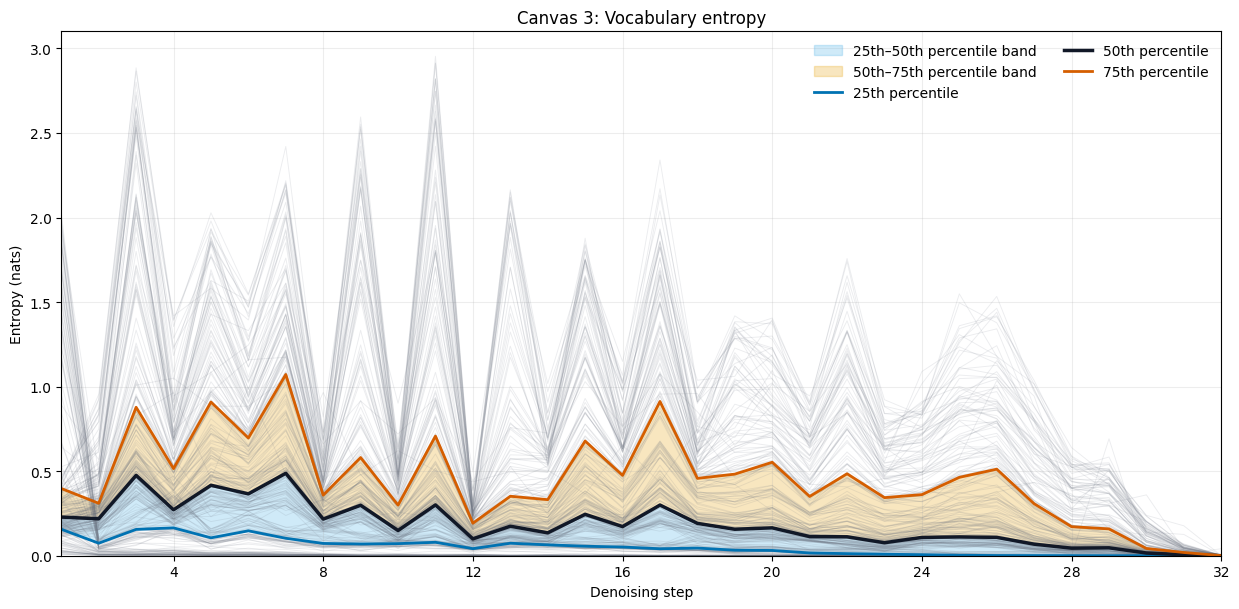

Saved diffusiongemma_plotting/canvas_03_entropy_trajectories.png


Saved diffusiongemma_plotting/canvas_03_kl_previous_canvas.mp4


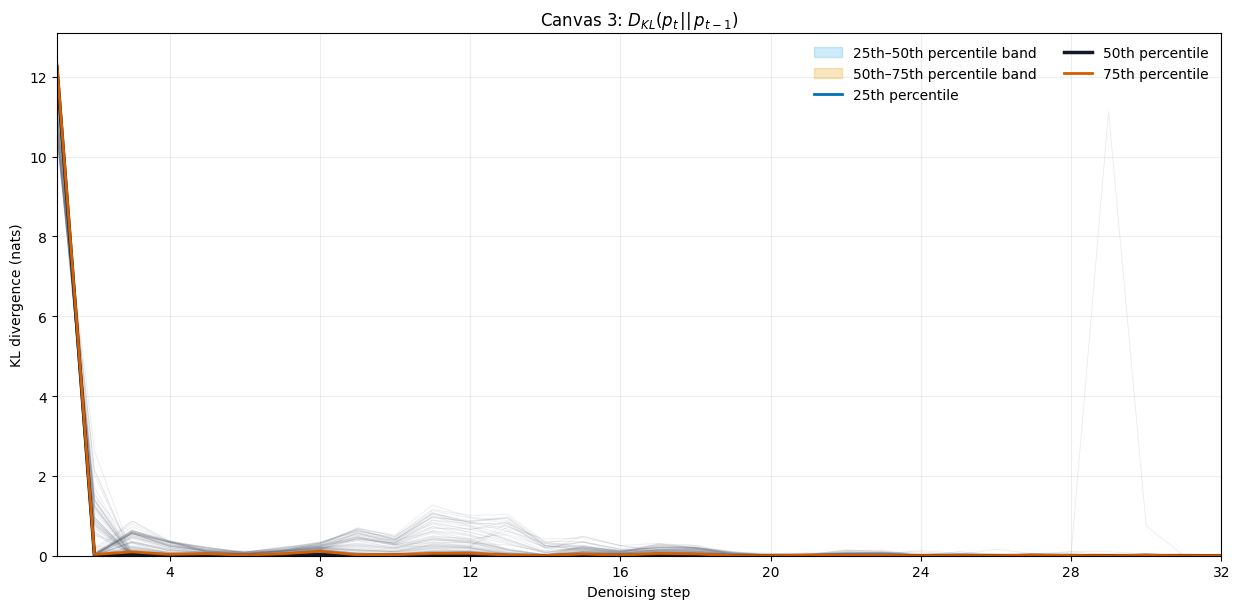

Saved diffusiongemma_plotting/canvas_03_kl_previous_trajectories.png


Saved diffusiongemma_plotting/canvas_03_kl_final_canvas.mp4


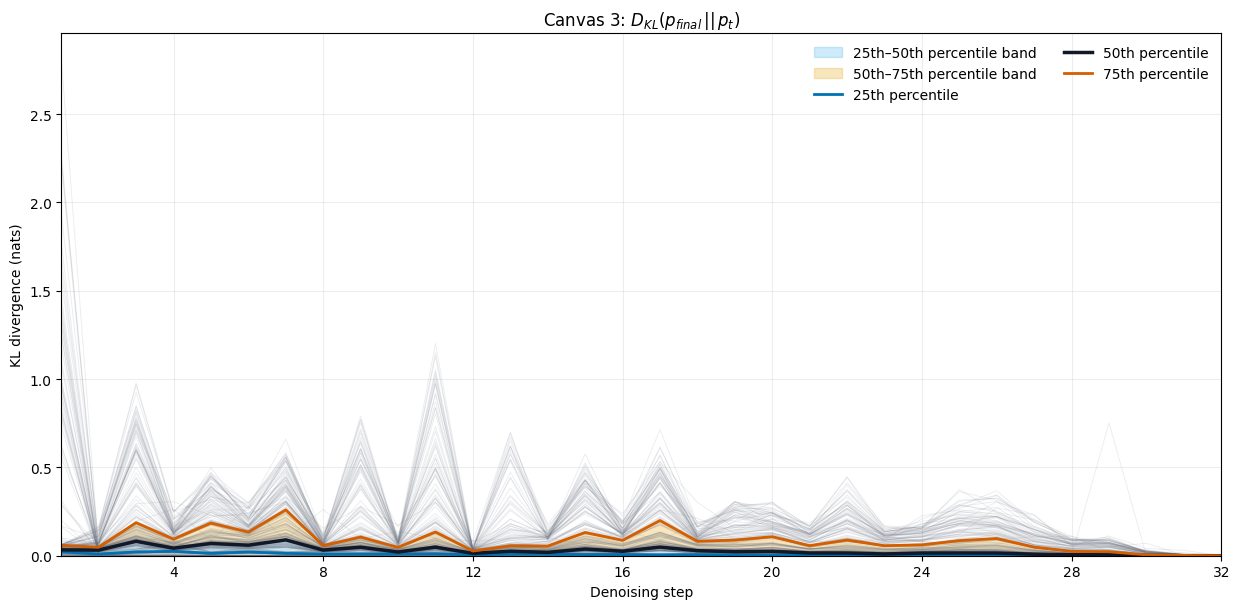

Saved diffusiongemma_plotting/canvas_03_kl_final_trajectories.png


Saved diffusiongemma_plotting/canvas_03_finalized_canvas.mp4


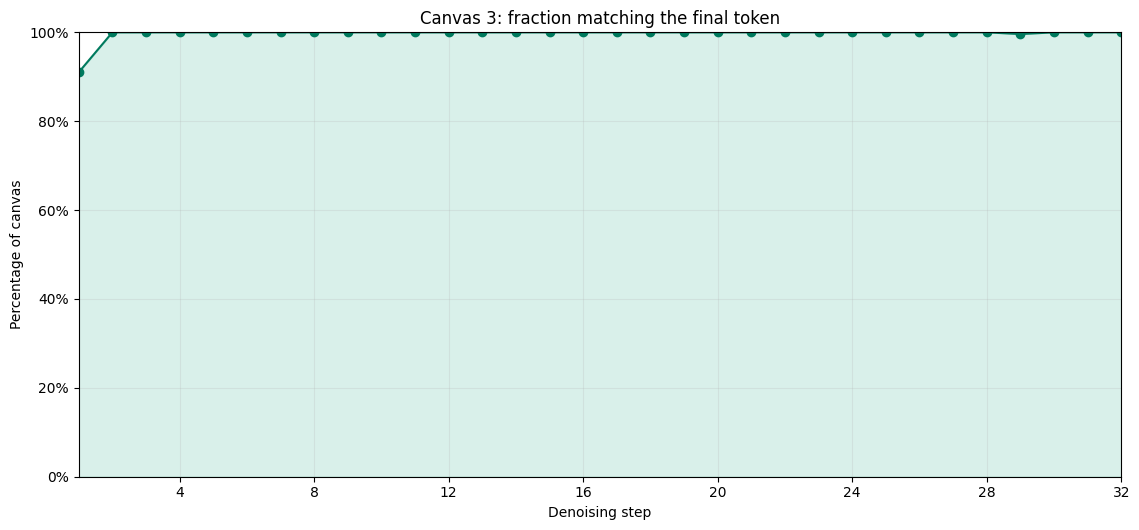

Saved diffusiongemma_plotting/canvas_03_finalized_fraction.png


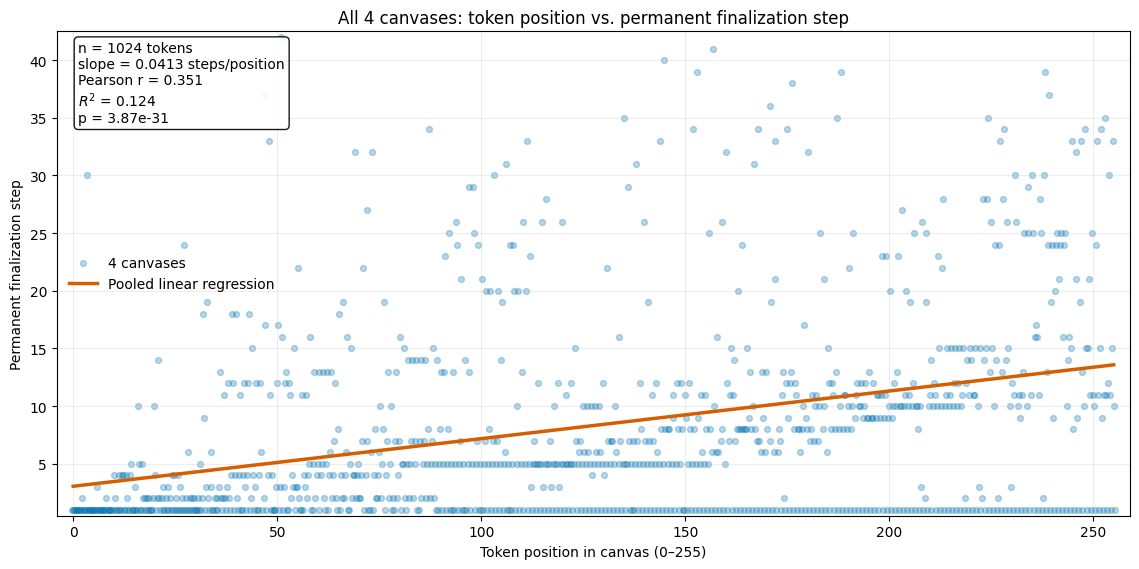

Saved diffusiongemma_plotting/all_canvases_position_finalization_regression.png
Pooled position/finalization association across 4 canvases at α=0.05: detected (r=0.351, R²=0.124, p=3.87e-31).


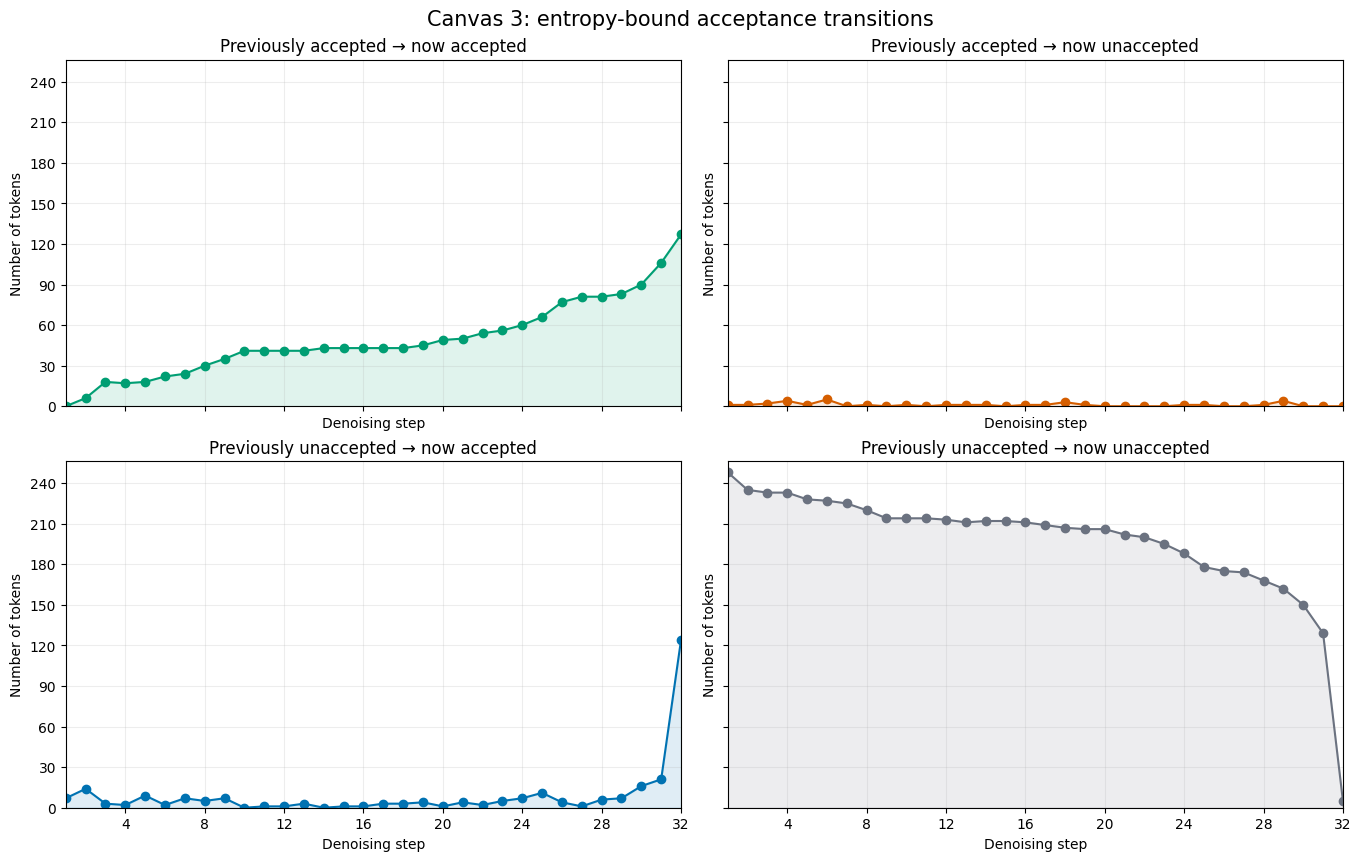

Saved diffusiongemma_plotting/canvas_03_acceptance_transitions.png


In [64]:
out.mkdir(parents=True, exist_ok=True)
logits = [x.detach() for x in plotting_data[canvas_idx]]
T, P, V = len(logits), *logits[0].shape
assert P == 256 and all(x.shape == (P, V) for x in logits)
steps, logV = np.arange(1, T + 1), float(np.log(V))

# Entropy, KL(p_t || p_{t-1}), KL(p_final || p_t), and argmax token IDs.
metrics = torch.empty((3, T, P), dtype=torch.float32, device="cpu")
ids = torch.empty((T, P), dtype=torch.long, device="cpu")
with torch.inference_mode():
    for start in range(0, P, 32):
        sl = slice(start, min(start + 32, P))
        final_lp = logits[-1][sl].float().log_softmax(-1)
        final_p, previous_lp = final_lp.exp(), None
        for t, z in enumerate(logits):
            lp = z[sl].float().log_softmax(-1)
            p = lp.exp()
            h = -(p * lp).sum(-1)
            metrics[0, t, sl] = h
            metrics[1, t, sl] = (logV - h if previous_lp is None else (p * (lp - previous_lp)).sum(-1)).clamp_min(0)
            metrics[2, t, sl] = (final_p * (final_lp - lp)).sum(-1).clamp_min(0)
            ids[t, sl] = z[sl].argmax(-1)
            previous_lp = lp

entropy, kl_previous, kl_final = metrics.numpy()
ids = ids.numpy()
finalized = ids == ids[-1]

# Reconstruct the sampler's entropy-bound acceptance state, including uniform initialization.
def acceptance(h):
    sorted_h, order = h.sort(-1)
    keep = sorted_h.cumsum(-1) - sorted_h <= float(entropy_bound)
    return torch.zeros_like(keep).scatter(-1, order, keep)

accepted = acceptance(torch.cat((torch.full((1, P), logV, device="cpu"), torch.from_numpy(entropy))))
previous, current = accepted[:-1], accepted[1:]
transitions = torch.stack((previous & current, previous & ~current,
                           ~previous & current, ~previous & ~current)).sum(-1).numpy()
assert np.all(transitions.sum(0) == P)


def token_piece(token_id, width=9):
    try:
        text = str(tok.id_to_token(int(token_id)) or f"#{token_id}")
    except Exception:
        text = f"#{token_id}"
    for old, new in (("<0x0A>", "↵"), ("<0x09>", "⇥"), ("▁", "·"), ("Ġ", "·"),
                     ("Ċ", "↵"), ("\n", "↵"), ("\t", "⇥"), (" ", "·")):
        text = text.replace(old, new)
    text = text.replace("\r", "") or "∅"
    return text if len(text) <= width else text[:width - 1] + "…"


def show_save(fig, name, ani=None, fps=4, indexed=True):
    base = out / (f"canvas_{canvas_idx:02d}_{name}" if indexed else name)
    if ani is None:
        path = base.with_suffix(".png")
        fig.savefig(path, dpi=160, bbox_inches="tight")
        display(fig)
    else:
        mp4 = animation.writers.is_available("ffmpeg")
        path = base.with_suffix(".mp4" if mp4 else ".gif")
        writer = animation.FFMpegWriter(fps=fps) if mp4 else animation.PillowWriter(fps=fps)
        ani.save(path, writer=writer, dpi=100)
        display(Video(str(path), embed=True) if mp4 else Image(filename=str(path)))
    plt.close(fig)
    print(f"Saved {path}")


def canvas_video(values, title, name, label=None, binary=False, fps=4):
    values = np.asarray(values)
    cmap = colors.ListedColormap(["#F1F5F9", "#007A5E"]) if binary else plt.get_cmap("cividis")
    lo, hi = (0, 1) if binary else (np.nanmin(values), np.nanmax(values))
    norm = colors.Normalize(lo, hi if hi > lo else lo + 1)
    fig, ax = plt.subplots(figsize=(10.5, 9.5))
    image = ax.imshow(values[0].reshape(16, 16), cmap=cmap, norm=norm, interpolation="nearest")
    labels = [ax.text(c, r, "", ha="center", va="center", fontsize=5.4, family="monospace")
              for r in range(16) for c in range(16)]
    ax.set(xlabel="Canvas column", ylabel="Canvas row")
    ax.set_xticks(range(0, 16, 4)); ax.set_yticks(range(0, 16, 4))
    ax.set_xticks(np.arange(-.5, 16), minor=True); ax.set_yticks(np.arange(-.5, 16), minor=True)
    ax.grid(which="minor", color="white", linewidth=.55)
    ax.tick_params(which="minor", bottom=False, left=False)
    bar = fig.colorbar(image, ax=ax, fraction=.046, pad=.04)
    if binary:
        bar.set_ticks([0, 1]); bar.set_ticklabels(["Not final", "Final"])
    else:
        bar.set_label(label)

    def draw(t):
        frame = values[t]
        image.set_data(frame.reshape(16, 16))
        suffix = f" ({100 * frame.mean():.1f}% finalized)" if binary else ""
        ax.set_title(f"{title} — step {t + 1}/{T}{suffix}")
        for artist, token_id, value in zip(labels, ids[t], frame):
            r, g, b = cmap(norm(value))[:3]
            artist.set(text=token_piece(token_id),
                       color="#111111" if .2126*r + .7152*g + .0722*b > .52 else "white",
                       fontweight="bold" if binary and value else "normal")
        return image, *labels

    ani = animation.FuncAnimation(fig, draw, frames=T, interval=1000/fps, repeat=True)
    draw(0); fig.tight_layout(); show_save(fig, name, ani, fps)


def trajectory_plot(values, title, name, ylabel):
    q25, q50, q75 = np.percentile(values, (25, 50, 75), axis=1)
    fig, ax = plt.subplots(figsize=(12.5, 6.2))
    ax.plot(steps, values, color="#6B7280", alpha=.13, linewidth=.65)
    ax.fill_between(steps, q25, q50, color="#56B4E9", alpha=.28, label="25th–50th percentile band")
    ax.fill_between(steps, q50, q75, color="#E69F00", alpha=.25, label="50th–75th percentile band")
    for q, color, label, width in ((q25, "#0072B2", "25th percentile", 2),
                                    (q50, "#111827", "50th percentile", 2.5),
                                    (q75, "#D55E00", "75th percentile", 2)):
        ax.plot(steps, q, color=color, linewidth=width, label=label)
    ax.set(title=f"Canvas {canvas_idx}: {title}", xlabel="Denoising step", ylabel=ylabel,
           xlim=(.5, 1.5) if T == 1 else (1, T), ylim=(0, None))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(alpha=.22); ax.legend(ncol=2, frameon=False)
    fig.tight_layout(); show_save(fig, name)


for name, values, title, ylabel in (
    ("entropy", entropy, "Vocabulary entropy", "Entropy (nats)"),
    ("kl_previous", kl_previous, r"$D_{KL}(p_t\,||\,p_{t-1})$", "KL divergence (nats)"),
    ("kl_final", kl_final, r"$D_{KL}(p_{final}\,||\,p_t)$", "KL divergence (nats)"),
):
    canvas_video(values, title, f"{name}_canvas", ylabel)
    trajectory_plot(values, title, f"{name}_trajectories", ylabel)

canvas_video(finalized, "Positions matching their final token", "finalized_canvas", binary=True)

fig, ax = plt.subplots(figsize=(11.5, 5.4))
finalized_pct = 100 * finalized.mean(1)
ax.plot(steps, finalized_pct, marker="o", color="#007A5E")
ax.fill_between(steps, finalized_pct, color="#009E73", alpha=.15)
ax.set(title=f"Canvas {canvas_idx}: fraction matching the final token", xlabel="Denoising step",
       ylabel="Percentage of canvas", xlim=(.5, 1.5) if T == 1 else (1, T), ylim=(0, 100))
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)); ax.yaxis.set_major_formatter(ticker.PercentFormatter())
ax.grid(alpha=.22); fig.tight_layout(); show_save(fig, "finalized_fraction")

def permanent_finalization(token_ids):
    matches = token_ids == token_ids[-1]
    return np.logical_and.accumulate(matches[::-1], axis=0)[::-1].argmax(0) + 1

all_finalization = []
for i, canvas in enumerate(plotting_data):
    canvas_ids = ids if i == canvas_idx else np.stack([z.argmax(-1).cpu().numpy() for z in canvas])
    all_finalization.append(permanent_finalization(canvas_ids))
all_finalization = np.stack(all_finalization)
C, position = len(all_finalization), np.arange(P)
x, y = np.tile(position, C), all_finalization.ravel()
fit = linregress(x, y)
jitter = np.linspace(-.35, .35, C)[:, None] if C > 1 else 0
fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.scatter((position + jitter).ravel(), y, s=18, alpha=.28, color="#0072B2", label=f"{C} canvases")
ax.plot(position, fit.intercept + fit.slope * position, color="#D55E00", linewidth=2.5, label="Pooled linear regression")
ax.text(.02, .98, f"n = {x.size} tokens\nslope = {fit.slope:.4f} steps/position\n"
        f"Pearson r = {fit.rvalue:.3f}\n$R^2$ = {fit.rvalue**2:.3f}\np = {fit.pvalue:.3g}",
        transform=ax.transAxes, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=.9))
ax.set(title=f"All {C} canvases: token position vs. permanent finalization step",
       xlabel="Token position in canvas (0–255)", ylabel="Permanent finalization step",
       xlim=(-4, P + 3), ylim=(.5, y.max() + .5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True)); ax.grid(alpha=.22); ax.legend(frameon=False)
fig.tight_layout(); show_save(fig, "all_canvases_position_finalization_regression", indexed=False)
print(f"Pooled position/finalization association across {C} canvases at α=0.05: "
      f"{'detected' if fit.pvalue < .05 else 'not detected'} "
      f"(r={fit.rvalue:.3f}, R²={fit.rvalue**2:.3f}, p={fit.pvalue:.3g}).")

transition_titles = ("Previously accepted → now accepted", "Previously accepted → now unaccepted",
                     "Previously unaccepted → now accepted", "Previously unaccepted → now unaccepted")
transition_colors = ("#009E73", "#D55E00", "#0072B2", "#6B7280")
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5), sharex=True, sharey=True, constrained_layout=True)
for ax, values, title, color in zip(axes.flat, transitions, transition_titles, transition_colors):
    ax.plot(steps, values, marker="o", color=color)
    ax.fill_between(steps, values, color=color, alpha=.12)
    ax.set(title=title, xlabel="Denoising step", ylabel="Number of tokens",
           xlim=(.5, 1.5) if T == 1 else (1, T), ylim=(0, P))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)); ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(alpha=.22)
fig.suptitle(f"Canvas {canvas_idx}: entropy-bound acceptance transitions", fontsize=15)
show_save(fig, "acceptance_transitions")

Disclaimer: the code for this section was generated Gemini, with the following prompt:

```Make a video of the canvas over time, each token should be highlighted in a color proportional to the entropy of the corresponding vocab distribution at that position. Choose colors to make it easy to read.

Entropy over time for every line on the same graph (256 lines), the 25th, 50th, 75th percentile bands highlighted

Make another video of the canvas over time in the same way, but instead of entropy, use the KL divergence of the current distribution from the previous distribution

Make another graph in the same way, but the y axis is the divergence instead

Make another video of the canvas over time in the same way, but instead of entropy, use the KL divergence of the final distribution from the current distribution

Make another graph in the same way, but the y axis is the divergence to final instead

Make another video of the canvas over time, but highlight only the tokens that are equal to their final token (finalized) at each time step

Fraction of canvas finalized (matches the final token at that position) for the ith denoising step (y-axis should be percentage of canvas)

Generate a 2x2 , clear to read visual with four graphs. Each token position goes from (previously accepted -> now accepted) or (previously accepted -> now unaccepted)  or (previously unaccepted -> now accepted) or (previously unaccepted -> now unaccepted). The units on y-axis should be number of tokens.

A scatterplot + lin reg to answer the question: is the position of the token in the canvas correlated with the denoising step at when its finalized?

### Next: Bag of tricks for speeding up diffusiongemma inference

- Top-K self conditioning: The post-softmax distribution is very sparse / long-tailed, we can way compress the self-conditioning input without losing much information
- Instead of only precomputing RoPe frequencies, precompute the cos / sin vectors (compressed rotation matrix) for every position index. Can do the same thing for attention masks.
- Many rms norms can be fused / skipped, by separately considering it's unit-norm effect (only need to do once) from its multiply-by-weight effect (can fuse with nearby), e.g., for back to back rms's
- Interleaved / sliding window block diffusion / move canvas partially forward as soon as possible (feasible since emperically it seems number of accepted $\rightarrow$ unaccepted tokens is very small)
- Pass the pre-unembed hidden state between denoising steps instead. Let this be $v$ and the embedding matrix $W$. Instead of $\operatorname{softmax}(vW^\top)W$, compute $(vW^\top)W = v(W^\top W)$, which is a single $O(BD^2)$ matmul instead of two $O(BDV)$ matmuls plus a softmax. Note that $W^\top W$ can be precomputed. The next denoising step would similarly get information about the previous' confidence, but this would require retraining to take in logits.

Next: What did the conditioning MLP actually learn? Note that it operates on each element along the seq dim independently, small MLP capacity, and is not conditioned on the token -- suspect something interpretable.

Next: How do the *mechanisms* of attention learned by diffusion LLM differ from autoregressive, e.g., Does attention sink also exist for the non-casual self-attention? Are activations similarly low-rank? Why should weight sharing between encode and decode work? What does the [QK space](https://timothygao8710.github.io/QK-Visualizer/) look like -- effects of shared KV? Tuned lens / Layer skip? How interpretable are intermediate features?

# References:

- O’Donoghue, Brendan, and Sebastian Flennerhag. “[DiffusionGemma: 4x faster text generation](https://blog.google/innovation-and-ai/technology/developers-tools/diffusion-gemma-faster-text-generation/).” *Google*, 2026.
- Google AI for Developers. “[DiffusionGemma model overview](https://ai.google.dev/gemma/docs/diffusiongemma).”
- Google AI for Developers. “[Diffusion in Text Generation Explained](https://ai.google.dev/gemma/docs/diffusiongemma/explained).”
- Google DeepMind. “[DiffusionGemma 26B-A4B-IT model card](https://huggingface.co/google/diffusiongemma-26B-A4B-it).” *Hugging Face*.
- Google DeepMind. “[Gemma 4 model card](https://ai.google.dev/gemma/docs/core/model_card_4).”
- Google DeepMind. “[DiffusionGemma reference sampler](https://github.com/google-deepmind/gemma/blob/main/gemma/diffusion/_sampler.py).” *Gemma* repository.
- vLLM Team and Google DeepMind Team. “[DiffusionGemma: The First Diffusion LLM Natively Supported in vLLM](https://vllm-project.github.io/2026/06/10/diffusion-gemma).” *vLLM Blog*, 2026.
- Grootendorst, Maarten. “[A Visual Guide to DiffusionGemma](https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-diffusiongemma).” *Exploring Language Models*, 2026.
- Su, Jianlin, et al. “[RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864).” arXiv:2104.09864, 2021.
- Vaswani, Ashish, et al. “[Attention Is All You Need](https://arxiv.org/abs/1706.03762).” *Advances in Neural Information Processing Systems* 30, 2017.
- Kayyam, Ali, Anusha Madan Gopal, and M. Anthony Lewis. “[Do Transformers Need Three Projections? Systematic Study of QKV Variants](https://arxiv.org/abs/2606.04032).” arXiv:2606.04032, 2026.
- Elhage, Nelson, et al. “[A Mathematical Framework for Transformer Circuits](https://transformer-circuits.pub/2021/framework/index.html).” *Transformer Circuits Thread*, 2021.
- Roos, Daan, et al. “[Categorical Flow Maps](https://arxiv.org/abs/2602.12233).” arXiv:2602.12233, 2026.
- Austin, Jacob, et al. “[Sharded Matrices and How to Multiply Them](https://jax-ml.github.io/scaling-book/sharding/).” *How To Scale Your Model*, 2025.